In [24]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import math

import pickle


from sklearn import linear_model

In [3]:
df = pd.read_csv(r"C:\Users\gsksd\Downloads\homeprices.csv")
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsville,2600,575000


[]

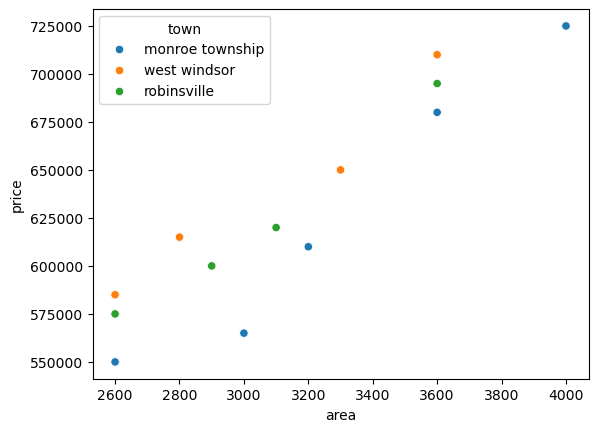

In [6]:
sns.scatterplot(data = df , x='area' , y='price' , hue = 'town')
plt.plot()

In [7]:
dummies = pd.get_dummies(df.town)
dummies

,monroe township,robinsville,west windsor
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
5,False,False,True
6,False,False,True
7,False,False,True
8,False,False,True
9,False,True,False


In [8]:
merged = pd.concat([df,dummies],axis='columns')
merged

,town,area,price,monroe township,robinsville,west windsor
0,monroe township,2600,550000,True,False,False
1,monroe township,3000,565000,True,False,False
2,monroe township,3200,610000,True,False,False
3,monroe township,3600,680000,True,False,False
4,monroe township,4000,725000,True,False,False
5,west windsor,2600,585000,False,False,True
6,west windsor,2800,615000,False,False,True
7,west windsor,3300,650000,False,False,True
8,west windsor,3600,710000,False,False,True
9,robinsville,2600,575000,False,True,False


In [10]:
final = merged.drop(['town' , 'west windsor'], axis = 'columns')
final

,area,price,monroe township,robinsville
0,2600,550000,True,False
1,3000,565000,True,False
2,3200,610000,True,False
3,3600,680000,True,False
4,4000,725000,True,False
5,2600,585000,False,False
6,2800,615000,False,False
7,3300,650000,False,False
8,3600,710000,False,False
9,2600,575000,False,True


In [12]:
X = final.drop(['price'], axis = 1)
X

,area,monroe township,robinsville
0,2600,True,False
1,3000,True,False
2,3200,True,False
3,3600,True,False
4,4000,True,False
5,2600,False,False
6,2800,False,False
7,3300,False,False
8,3600,False,False
9,2600,False,True


In [13]:
y = final.price
y

0     550000
1     565000
2     610000
3     680000
4     725000
5     585000
6     615000
7     650000
8     710000
9     575000
10    600000
11    620000
12    695000
Name: price, dtype: int64

In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [15]:
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
model.predict(X) 


array([539709.7398409 , 590468.71640508, 615848.20468716, 666607.18125134,
       717366.15781551, 579723.71533005, 605103.20361213, 668551.92431735,
       706621.15674048, 565396.15136531, 603465.38378844, 628844.87207052,
       692293.59277574])

In [17]:
model.score(X,y)

0.9573929037221873

In [18]:
model.predict([[4000 , 0 ,0 ]])

C:\Users\gsksd\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([757380.13330465])

In [22]:
model.coef_


array([   126.89744141, -40013.97548914, -14327.56396474])

In [23]:
model.intercept_

np.float64(249790.36766292533)

In [31]:
import pickle

with open('houseprices.pkl', 'wb') as file:
    pickle.dump(model, file)

In [32]:
import os
print(os.getcwd())

C:\Users\gsksd


In [33]:
import os
print(os.path.exists('houseprices.pkl'))


True


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Load dataset
df = pd.read_csv(r"C:\Users\gsksd\Downloads\homeprices.csv")

# Features and target
x = df['area'].values
y = df['price'].values

# Normalize for faster convergence
x = x / max(x)
y = y / max(y)

# Initialize parameters
m = 0
c = 0

# Hyperparameters
learning_rate = 0.1
epochs = 100

n = len(x)

for epoch in range(epochs):

    # Predictions
    y_pred = m * x + c

    # Cost (MSE)
    cost = (1/n) * np.sum((y - y_pred)**2)

    # Derivatives
    dm = -(2/n) * np.sum(x * (y - y_pred))
    dc = -(2/n) * np.sum(y - y_pred)

    # Update parameters
    m = m - learning_rate * dm
    c = c - learning_rate * dc

    # Plot every 5 iterations
    if epoch % 5 == 0:

        clear_output(wait=True)

        plt.figure(figsize=(8,5))
        plt.scatter(x, y, label='Actual Data')
        plt.plot(x, y_pred, linewidth=2, label='y = mx + c')

        plt.title(f"Epoch {epoch}")
        plt.xlabel("Area (Normalized)")
        plt.ylabel("Price (Normalized)")
        plt.legend()

        plt.show()

        print(f"Epoch: {epoch}")
        print(f"m = {m:.4f}")
        print(f"c = {c:.4f}")
        print(f"Cost = {cost:.6f}")

        time.sleep(0.1)

print("\nTraining Complete")
print(f"Final m = {m}")
print(f"Final c = {c}")

FileNotFoundError: [Errno 2] No such file or directory: 'homeprices.csv'